**Model Interpretation and Insights**

**Objective**

Interpret the final Logistic Regression churn model to understand which features drive customer churn and translate model outputs into actionable business insights.

**Importing Libraries**

In [7]:
# Core
import numpy as np
import pandas as pd


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Model loading
import joblib

**Load Processed Data**

In [8]:
df = pd.read_csv('../data/processed/Telco-Customer-Churn-processed.csv')


X = df.drop('Churn', axis=1)
y = df['Churn']

**Load Final Model**

In [9]:
model = joblib.load('../models/logistic_regression_churn_model.pkl')

 **Extract Model Coefficients**

In [10]:
coefficients = pd.DataFrame({
'feature': X.columns,
'coefficient': model.coef_[0]
})


coefficients['abs_coefficient'] = coefficients['coefficient'].abs()
coefficients = coefficients.sort_values('abs_coefficient', ascending=False)
coefficients.head(10)

,feature,coefficient,abs_coefficient
2,MonthlyCharges,-2.185577,2.185577
10,InternetService_Fiber optic,1.294387,1.294387
1,tenure,-1.283314,1.283314
25,Contract_Two year,-0.589586,0.589586
3,TotalCharges,0.560404,0.560404
23,StreamingMovies_Yes,0.460868,0.460868
21,StreamingTV_Yes,0.459563,0.459563
9,MultipleLines_Yes,0.319570,0.319570
24,Contract_One year,-0.283890,0.283890
26,PaperlessBilling_Yes,0.181534,0.181534


**Top Features Driving Churn**

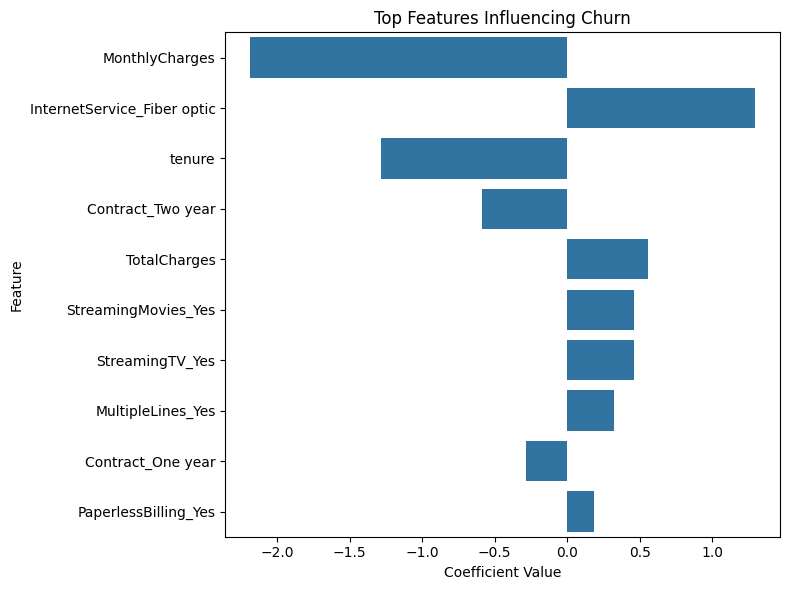

In [11]:
plt.figure(figsize=(8, 6))
sns.barplot(
data=coefficients.head(10),
x='coefficient',
y='feature'
)
plt.title('Top Features Influencing Churn')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Positive vs Negative Impact Analysis**

In [12]:
positive_features = coefficients[coefficients['coefficient'] > 0].head(10)
negative_features = coefficients[coefficients['coefficient'] < 0].head(10)


positive_features, negative_features

(                           feature  coefficient  abs_coefficient
 10     InternetService_Fiber optic     1.294387         1.294387
 3                     TotalCharges     0.560404         0.560404
 23             StreamingMovies_Yes     0.460868         0.460868
 21                 StreamingTV_Yes     0.459563         0.459563
 9                MultipleLines_Yes     0.319570         0.319570
 26            PaperlessBilling_Yes     0.181534         0.181534
 28  PaymentMethod_Electronic check     0.181431         0.181431
 17            DeviceProtection_Yes     0.151605         0.151605
 7                 PhoneService_Yes     0.130975         0.130975
 15                OnlineBackup_Yes     0.085989         0.085989,
                                  feature  coefficient  abs_coefficient
 2                         MonthlyCharges    -2.185577         2.185577
 1                                 tenure    -1.283314         1.283314
 25                     Contract_Two year    -0.589586   

**Business Insights**

**Features that increase churn risk**

Customers on month-to-month contracts show a significantly higher likelihood of churn, indicating low commitment and higher price sensitivity.

Fiber optic internet users are more likely to churn, likely due to higher costs and elevated service expectations.

Customers using electronic check payment methods exhibit higher churn, which may reflect less stable billing behavior or lower engagement.

Higher monthly charges are associated with increased churn, especially among newer customers.

**Features that reduce churn risk**

Long-term contracts (one-year and two-year) strongly reduce churn, suggesting commitment is a key retention factor.

Longer tenure significantly lowers churn probability, reinforcing that churn risk is highest early in the customer lifecycle.

Customers with online security, tech support, and backup services are less likely to churn, indicating bundled services improve stickiness.

Having dependents or a partner is associated with lower churn, possibly reflecting more stable usage patterns.

**Business strategy implications**

Focus retention efforts on new customers within the first few months, especially those on month-to-month plans.

Incentivize migration from month-to-month to longer-term contracts through discounts or loyalty benefits.

Re-evaluate pricing and service quality expectations for fiber optic customers.

Promote value-added services such as online security and tech support to increase customer stickiness.

**Key Takeaways**

**Most important churn drivers**

Contract type is the strongest churn driver, with month-to-month customers being far more likely to churn than those on long-term contracts.

Tenure has a strong inverse relationship with churn, meaning customers are most at risk early in their lifecycle.

Monthly charges increase churn risk, especially when paired with short-term contracts.

Customers using fiber optic internet and electronic check payments exhibit higher churn rates, likely due to cost sensitivity and service expectations.

**Potential retention strategies**

Introduce early-life retention programs targeting new customers within their first few months.

Offer incentives to switch from month-to-month to annual contracts, such as discounts or bundled services.

Improve perceived value for high-paying customers by bundling tech support, online security, or backup services.

Target high-risk segments with personalized offers instead of broad discounts to protect revenue.

**Limitations of linear model interpretation**

Logistic regression assumes a linear relationship between features and the log-odds of churn, which may oversimplify complex customer behavior.

The model does not capture non-linear interactions between features unless explicitly engineered.

Feature importance reflects association, not causation, meaning identified drivers may correlate with churn rather than directly cause it.

Results may be sensitive to multicollinearity, especially among pricing and service-related features.